# Sentiment EDA

Phase 2 notebook for sentiment class balance, review length, star ratings, and top TF-IDF terms.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

DATA_PATH = Path('../data/raw/reviews.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('data/raw/reviews.csv')

reviews = pd.read_csv(DATA_PATH)
reviews.head()

,review_id,review_text,star_rating,sentiment_label
0,REV-00001,"We had repeated issues, outages, and delayed r...",2,negative
1,REV-00002,Poor experience with confusing billing and mis...,1,negative
2,REV-00003,Support answered eventually and the product is...,3,neutral
3,REV-00004,Great experience with fast fixes and clear com...,4,positive
4,REV-00005,"The product feels stable, useful, and worth th...",4,positive


In [2]:
print('Shape:', reviews.shape)
display(reviews.info())
display(reviews.isna().sum())
display(reviews['sentiment_label'].value_counts())

Shape: (3000, 4)
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   review_id        3000 non-null   str  
 1   review_text      3000 non-null   str  
 2   star_rating      3000 non-null   int64
 3   sentiment_label  3000 non-null   str  
dtypes: int64(1), str(3)
memory usage: 353.0 KB


None

review_id          0
review_text        0
star_rating        0
sentiment_label    0
dtype: int64

sentiment_label
negative    1000
neutral     1000
positive    1000
Name: count, dtype: int64

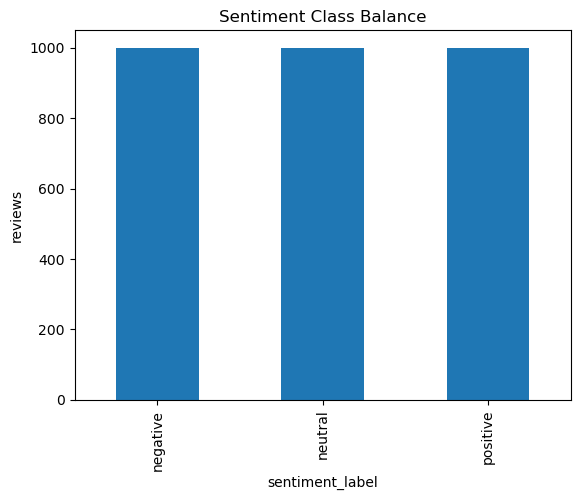

In [3]:
label_counts = reviews['sentiment_label'].value_counts().sort_index()
label_counts.plot(kind='bar', title='Sentiment Class Balance')
plt.xlabel('sentiment_label')
plt.ylabel('reviews')
plt.show()

,count,mean,median,min,max
sentiment_label,,,,,
negative,1000,10.89,9.0,8,20
neutral,1000,10.93,9.0,8,20
positive,1000,11.16,9.0,7,20


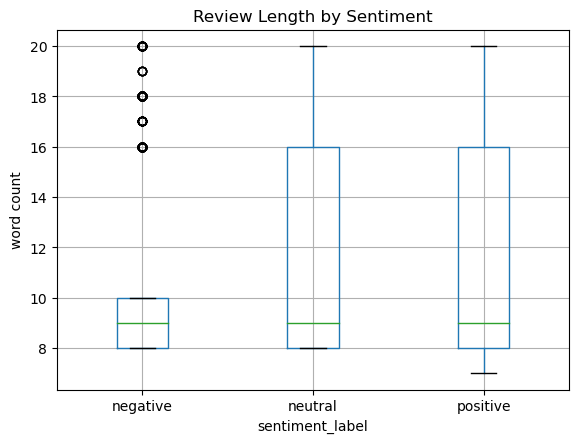

In [4]:
reviews['review_length_words'] = reviews['review_text'].str.split().str.len()
display(reviews.groupby('sentiment_label')['review_length_words'].agg(['count', 'mean', 'median', 'min', 'max']).round(2))
reviews.boxplot(column='review_length_words', by='sentiment_label')
plt.title('Review Length by Sentiment')
plt.suptitle('')
plt.xlabel('sentiment_label')
plt.ylabel('word count')
plt.show()

In [5]:
display(reviews.groupby('sentiment_label')['star_rating'].agg(['mean', 'min', 'max']).round(2))

,mean,min,max
sentiment_label,,,
negative,1.40,1,2
neutral,3.00,3,3
positive,4.62,4,5


In [6]:
top_terms = {}
for label in sorted(reviews['sentiment_label'].unique()):
    texts = reviews.loc[reviews['sentiment_label'] == label, 'review_text']
    vectorizer = TfidfVectorizer(stop_words='english', max_features=20, ngram_range=(1, 2))
    matrix = vectorizer.fit_transform(texts)
    scores = matrix.mean(axis=0).A1
    terms = sorted(zip(vectorizer.get_feature_names_out(), scores), key=lambda item: item[1], reverse=True)[:10]
    top_terms[label] = [term for term, score in terms]

display(pd.DataFrame.from_dict(top_terms, orient='index').T)

,negative,neutral,positive
0,billing,reporting,love
1,features,product,saves
2,missing,support,saves time
3,poor experience,support answered,time
4,failing,feel,time week
5,failing support,feel slow,week
6,keeps,slow,feels stable
7,keeps failing,workflows,product
8,slow,workflows feel,product feels
9,support,works,stable useful
